In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os
import sys
import glob
import math

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler, random_split
from torchvision import transforms, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from datasets import ISIC2018Dataset, TransformDataset

print(f"PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")

PyTorch 2.10.0+cu128 | CUDA available: True


In [ ]:
# ── Parameters (edit here) ────────────────────────────────────────────────────
DATASET_DIR         = "dataset/ISIC_2018/ISIC2018_Task3_Training_Input"
LABELS_CSV          = "dataset/ISIC_2018/ISIC2018_Task3_Training_GroundTruth.csv"
IMAGE_SIZE          = 224          # EfficientNet-B0 default
BATCH_SIZE          = 32
NUM_WORKERS         = 4
VAL_SPLIT           = 0.2          # fraction held out for validation
LEARNING_RATE       = 1e-4         # lower LR appropriate for fine-tuning
NUM_EPOCHS          = 40
LABEL_SMOOTHING     = 0.3          # aggressive label smoothing
CHECKPOINT_DIR      = "checkpoints/efficientnet_nv_mel_classifier/run_2"
AE_CHECKPOINT_DIR   = "checkpoints/efficientnet_nv_mel_ae_vgg"
DEVICE              = "cuda" if torch.cuda.is_available() else "cpu"
LABEL_NAMES         = ["NV", "MEL"]

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"Using device  : {DEVICE}")
print(f"Image size    : {IMAGE_SIZE} x {IMAGE_SIZE}")
print(f"Checkpoint dir: {os.path.abspath(CHECKPOINT_DIR)}")

Using device  : cuda
Image size    : 224 x 224
Checkpoint dir: /home/tejass_iitp/capstone/checkpoints/efficientnet_nv_mel_classifier/run_2


In [ ]:
# ── Transforms ───────────────────────────────────────────────────────────────
# Train: augmentations to reduce over-fitting on the small MEL class.
# Val  : deterministic centre-crop only.
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],   # ImageNet mean
                         [0.229, 0.224, 0.225]),   # ImageNet std
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

print("Transform pipelines defined.")

Transform pipelines defined.


In [ ]:
# ── Dataset & DataLoaders ─────────────────────────────────────────────────────
# Base dataset with transform=None so it returns raw PIL images.
# TransformDataset wraps each split with its own augmentation pipeline.

full_dataset = ISIC2018Dataset(
    root_dir       = DATASET_DIR,
    transform      = None,
    labels_csv     = LABELS_CSV,
    include_labels = LABEL_NAMES,
)

print(f"Total labeled samples (NV+MEL): {len(full_dataset)}")

# ── Train / Val split ─────────────────────────────────────────────────────────
n_total = len(full_dataset)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(42)
train_sub, val_sub = random_split(
    full_dataset, [n_train, n_val], generator=generator
)

train_dataset = TransformDataset(train_sub, train_transform)
val_dataset   = TransformDataset(val_sub,   val_transform)

print(f"Train samples : {len(train_dataset):,}")
print(f"Val   samples : {len(val_dataset):,}")

# ── Collect raw one-hot labels for WeightedRandomSampler (no image I/O) ──────
# label_map rows are [NV, MEL]; binary label = argmax
all_labels = [
    int(full_dataset.label_map.loc[
        os.path.splitext(os.path.basename(p))[0]
    ].values.argmax())
    for p in full_dataset.image_paths
]
class_counts = np.bincount(all_labels)
print(f"Class counts  : NV={class_counts[0]:,}  MEL={class_counts[1]:,}")

# ── WeightedRandomSampler on train split only ─────────────────────────────────
train_labels   = [all_labels[i] for i in train_sub.indices]
class_weights  = 1.0 / class_counts
sample_weights = [class_weights[lbl] for lbl in train_labels]
train_sampler  = WeightedRandomSampler(
    weights     = torch.DoubleTensor(sample_weights),
    num_samples = len(train_dataset),
    replacement = True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = train_sampler,
    num_workers = NUM_WORKERS,
    pin_memory  = DEVICE == "cuda",
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = DEVICE == "cuda",
)

print(f"Train batches/epoch : {len(train_loader)}")
print(f"Val   batches/epoch : {len(val_loader)}")

Found 10015 valid JPEG images in 'dataset/ISIC_2018/ISIC2018_Task3_Training_Input'
Total labeled samples (NV+MEL): 10015
Train samples : 8,012
Val   samples : 2,003
Class counts  : NV=8,902  MEL=1,113
Train batches/epoch : 251
Val   batches/epoch : 63
Class counts  : NV=8,902  MEL=1,113
Train batches/epoch : 251
Val   batches/epoch : 63


Batch shape : torch.Size([32, 3, 224, 224])
Labels (raw): [[1.0, 0.0], [0.0, 1.0], [0.0, 1.0], [0.0, 1.0], [0.0, 0.0], [1.0, 0.0], [1.0, 0.0], [1.0, 0.0]]


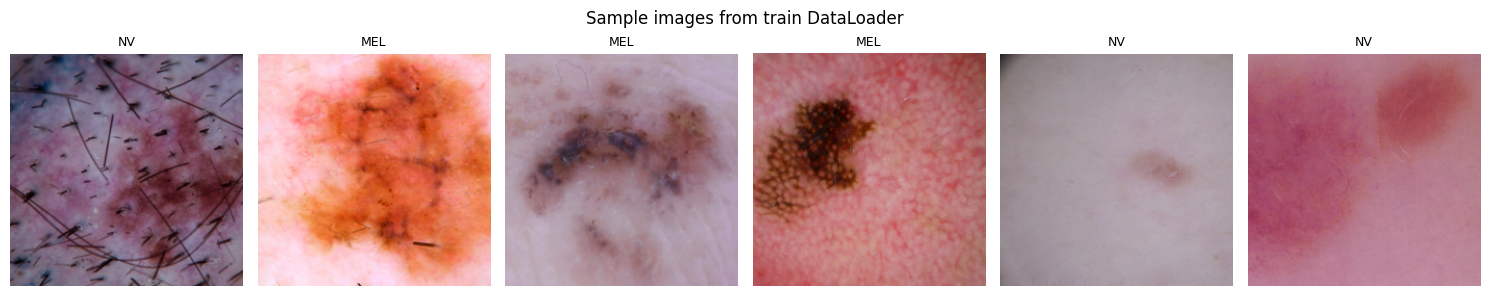

In [ ]:
# ── Sanity check: visualise a batch ──────────────────────────────────────────
sample_imgs, sample_labels = next(iter(train_loader))
print("Batch shape :", sample_imgs.shape)
print("Labels (raw):", sample_labels[:8].tolist())

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
for i, ax in enumerate(axes):
    img = sample_imgs[i].permute(1, 2, 0).numpy()
    img = (img * std + mean).clip(0, 1)
    cls = sample_labels[i].argmax().item()
    ax.imshow(img)
    ax.set_title(LABEL_NAMES[cls], fontsize=9)
    ax.axis("off")
plt.suptitle("Sample images from train DataLoader", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ── Model – EfficientNet-B0 with partial freezing ────────────────────────────
#
# EfficientNet-B0 feature extractor layout (model.features):
#   [0]  Conv2dNormActivation  – stem (32 filters)
#   [1]  Sequential            – MBConv block stage 1
#   [2]  Sequential            – MBConv block stage 2
#   [3]  Sequential            – MBConv block stage 3
#   [4]  Sequential            – MBConv block stage 4
#   [5]  Sequential            – MBConv block stage 5
#   [6]  Sequential            – MBConv block stage 6
#   [7]  Sequential            – MBConv block stage 7
#   [8]  Conv2dNormActivation  – head conv

backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

FREEZE_UP_TO = 0 # count includes stem
for i in range(FREEZE_UP_TO):
    for param in backbone.features[i].parameters():
        param.requires_grad = False

# Replace the classifier head: 1280-d → 1 (NV/MEL)
in_features = backbone.classifier[1].in_features
backbone.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(in_features, 1),
)

model = backbone.to(DEVICE)

frozen   = sum(p.numel() for p in model.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Frozen parameters   : {frozen:,}")
print(f"Trainable parameters: {trainable:,}")

Frozen parameters   : 0
Trainable parameters: 4,008,829


In [ ]:
# Load best classifier

existing = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, "epoch_*.pth")))
assert len(existing) > 0, "No classifier checkpoint found"

latest = existing[-1]
ckpt   = torch.load(latest, map_location="cpu", weights_only=False)
best_epoch_idx = ckpt["val_losses"].index(min(ckpt["val_losses"]))

best_ckpt = torch.load(existing[best_epoch_idx], map_location=DEVICE, weights_only=False)
model.load_state_dict(best_ckpt["model_state"])
model.eval()

print(f"Classifier: {latest[best_epoch_idx]}") # should be existing[best_epoch_idx]
print(f"    Val AUC: {best_ckpt['val_aucs'][best_epoch_idx]:.4f}")
print(f"    Val accuracy: {best_ckpt['val_accuracies'][best_epoch_idx]:.4f}")
print(f"    Val precision: {best_ckpt['val_precisions'][best_epoch_idx]:.4f}")
print(f"    Val recall: {best_ckpt['val_recalls'][best_epoch_idx]:.4f}")
print(f"    Val F1: {best_ckpt['val_f1s'][best_epoch_idx]:.4f}")
print(f"    Val confusion matrix:")
print(best_ckpt['val_conf_matrices'][best_epoch_idx])

Classifier: f
    Val AUC: 0.9259
    Val accuracy: 0.9516
    Val precision: 0.8862
    Val recall: 0.6549
    Val F1: 0.7532
    Val confusion matrix:
[[1758   19]
 [  78  148]]


In [ ]:
# Load best AE

backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

class EfficientNetAutoencoder(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder.features
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(1280, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
        )

    def forward(self, x):
        features = self.encoder(x)
        return self.decoder(features)

ae = EfficientNetAutoencoder(backbone).to(DEVICE)

existing = sorted(glob.glob(os.path.join(AE_CHECKPOINT_DIR, "epoch_*.pth")))
assert len(existing) > 0, "No AE checkpoint found"

latest = existing[-1]
ckpt   = torch.load(latest, map_location="cpu", weights_only=False)
best_epoch_idx = ckpt["val_losses"].index(min(ckpt["val_losses"]))

best_ckpt = torch.load(existing[best_epoch_idx], map_location=DEVICE, weights_only=False)
ae.load_state_dict(best_ckpt["model_state"])
ae.eval()

EfficientNetAutoencoder(
  (encoder): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dN

In [ ]:
all_logits       = []
all_targets      = []   # ground-truth class indices

with torch.no_grad():
    for imgs, labels_onehot in tqdm(val_loader, desc=f"Classifier on Raw vs AE", leave=False):
        imgs          = imgs.to(DEVICE, non_blocking=True)
        labels_onehot = labels_onehot.to(DEVICE, non_blocking=True)
        labels        = labels_onehot.argmax(dim=1)

        recons = ae(imgs)
        logits = model(recons).squeeze(-1)

        all_logits.extend(logits.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

all_preds = (np.array(all_logits) > 0).astype(int)
val_auc  = roc_auc_score(all_targets, all_logits)
val_acc  = accuracy_score(all_targets, all_preds)
val_prec = precision_score(all_targets, all_preds, zero_division=0)
val_rec  = recall_score(all_targets, all_preds, zero_division=0)
val_f1   = f1_score(all_targets, all_preds, zero_division=0)
val_cm   = confusion_matrix(all_targets, all_preds)

print(f"Classifier on Reconstructed Images:")
print(f"    Val AUC: {val_auc:.4f}")
print(f"    Val accuracy: {val_acc:.4f}")
print(f"    Val precision: {val_prec:.4f}")
print(f"    Val recall: {val_rec:.4f}")
print(f"    Val F1: {val_f1:.4f}")
print(f"    Val confusion matrix:")
print(val_cm)

Classifier on Reconstructed Images:
    Val AUC: 0.6612
    Val accuracy: 0.8882
    Val precision: 0.7500
    Val recall: 0.0133
    Val F1: 0.0261
    Val confusion matrix:
[[1776    1]
 [ 223    3]]
